## 버섯 데이터로 독성 분류 문제

In [1]:
import pandas as pd
data = pd.read_csv('./data/mushroom.csv')
data

,poisonous,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


### 데이터 크기 확인, 정보 확인, 분석

In [4]:
data.shape

(8124, 23)

데이터의 모든 Feature들에 대해 결측치가 존재하지 않으며, Dtype(DataType)이 object 형태

이전 시간의 데이터와의 차이: object 타입으로 그대로 Machine Learning을 돌리기에 부적합한 데이터 형태
  → 수치형 데이터로 변경 (인코딩)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   poisonous                 8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [6]:
# X는 22개의 Feature 들 이고
# y는 'poisonous' 컬럼

## X, y를 나누는 방법 3가지

# X = data.iloc[:, 1:]
# X = data.loc[:, 'cap-shape':]
X = data.drop('poisonous', axis = 1)
y = data['poisonous']

X

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,k,s,n,f,n,a,c,b,y,e,...,s,o,o,p,o,o,p,b,c,l
8120,x,s,n,f,n,a,c,b,y,e,...,s,o,o,p,n,o,p,b,v,l
8121,f,s,n,f,n,a,c,b,n,e,...,s,o,o,p,o,o,p,b,c,l
8122,k,y,n,f,y,f,c,n,b,t,...,k,w,w,p,w,o,e,w,v,l


In [7]:
# 2개의 class로 이루어진 정답 (이지선다)
y.value_counts()

poisonous
e    4208
p    3916
Name: count, dtype: int64

In [8]:
# 모두 범주형 데이터로 평균, 표준편차, 최대 최소 값 등이 없음
data.describe(include='all')

,poisonous,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [9]:
X['cap-shape'].unique()

array(['x', 'b', 's', 'f', 'k', 'c'], dtype=object)

## 원핫인코딩(One-hot Encoding)
값의 크고 작은 것에 의미가 없음에도, 숫자를 mapping하여 ('x':0, 'b ':1, 's':2,...) 진행하면 자칫 의미가 부여될수 있어 자주 사용되는 인코딩 방법
학습 데이터(X)중 하나 자기 자신이 속한 해당 Feature의 값에 1 나머지에 0을 채우는 방식으로
'cap-shape'이 'x'인 데이터는 [1,0,0,0,0,0]의 형태로 인코딩

In [10]:
X_one_hot = pd.get_dummies(X, dtype = 'int64')
X_one_hot

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0,0,0,0,0,1,0,0,1,0,...,1,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
2,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
3,0,0,0,0,0,1,0,0,0,1,...,1,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
8120,0,0,0,0,0,1,0,0,1,0,...,0,1,0,0,0,1,0,0,0,0
8121,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
8122,0,0,0,1,0,0,0,0,0,1,...,0,1,0,0,0,1,0,0,0,0


### train, test 분리

In [12]:
# 분리 비율 7:3, random_state 고정(21)
# train_test_split()
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_one_hot, y, test_size=0.3,
                                                   random_state = 21)

In [13]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(5686, 117) (5686,)
(2438, 117) (2438,)


### 모델링

In [14]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
tree.score(X_test, y_test)

1.0

위의 경우 1.0으로 다 맞춰 과대 적합을 의심할 수 있어 사전 가지치기 (Pre-pruning) 수행한다

In [15]:
tree2 = DecisionTreeClassifier(max_depth = 3)
tree2.fit(X_train, y_train)
tree2.score(X_test, y_test)

0.9868744872846595

## 시각화 보조 자료
외부 모듈인 graphviz 활용

http://webgraphviz.com/
".dot 파일" 만들어 내용을 위 사이트에 복사 붙여넣기

hyper parameter를 조정하며 사전 가지치기 (post-pruning) 진행 후 시각화 처리
###### 1. 모두 default 처리 된 tree
###### 2. max_depth = 3
###### 3. max_leaf_nodes = 6
###### 4. min_samples_split = 3000
###### 5. min_samples_leaf = 700

In [17]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree,  # 모델 이름
    out_file = './data/tree.dot',  # 저장 경로 및 파일 명
    class_names = ['독성','식용'],   # 정답 라벨의 출력 이름
    feature_names = X_one_hot.columns,   # 원핫 인코딩 한 컬럼 이름으로 feature 이름
    filled = True,
    impurity = True
)

In [18]:
export_graphviz(
    tree2,  # 모델 이름
    out_file = './data/tree2.dot',  # 저장 경로 및 파일 명
    class_names = ['독성','식용'],   # 정답 라벨의 출력 이름
    feature_names = X_one_hot.columns,   # 원핫 인코딩 한 컬럼 이름으로 feature 이름
    filled = True,
    impurity = True
)

In [19]:
# 모델 객체 생성
tree3 = DecisionTreeClassifier(max_leaf_nodes = 6)
tree3.fit(X_train, y_train)
export_graphviz(
    tree3,  # 모델 이름
    out_file = './data/tree3.dot',  # 저장 경로 및 파일 명
    class_names = ['독성','식용'],   # 정답 라벨의 출력 이름
    feature_names = X_one_hot.columns,   # 원핫 인코딩 한 컬럼 이름으로 feature 이름
    filled = True,
    impurity = True
)

# 모델 객체 생성
tree4 = DecisionTreeClassifier(min_samples_split = 3000)
tree4.fit(X_train, y_train)
export_graphviz(
    tree4,  # 모델 이름
    out_file = './data/tree4.dot',  # 저장 경로 및 파일 명
    class_names = ['독성','식용'],   # 정답 라벨의 출력 이름
    feature_names = X_one_hot.columns,   # 원핫 인코딩 한 컬럼 이름으로 feature 이름
    filled = True,
    impurity = True
)

# 모델 객체 생성
tree5 = DecisionTreeClassifier(min_samples_leaf = 700)
tree5.fit(X_train, y_train)
export_graphviz(
    tree5,  # 모델 이름
    out_file = './data/tree5.dot',  # 저장 경로 및 파일 명
    class_names = ['독성','식용'],   # 정답 라벨의 출력 이름
    feature_names = X_one_hot.columns,   # 원핫 인코딩 한 컬럼 이름으로 feature 이름
    filled = True,
    impurity = True
)

### 특성 선택
- 각 특성들의 중요도를 출력해보자 (지도학습에서 가능)
- 정답에 얼마만큼의 영향을 미치는 특성인가를 수치로 확인이 가능하다
- 각 특성들의 중요도는 0-1사이의 값을 가진다
- 모든 특성의 중요도 합은 1
- tree모델은 특성의 중요도가 높은 값을 상위 질문(root node)로 배치한다.

In [23]:
importance = tree.feature_importances_
importance

array([0.00000000e+00, 7.02226527e-04, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.80300008e-03,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 9.80819672e-03, 0.00000000e+00,
       0.00000000e+00, 1.17716728e-02, 0.00000000e+00, 6.19867522e-01,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       4.19676826e-05, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.75741192e-01, 0.00000000e+00, 0.00000000e+00,
      

In [26]:
im_df = pd.DataFrame(importance, index = X_one_hot.columns, columns = ['Importance'])
im_df.sort_values(by='Importance',ascending=False)

,Importance
odor_n,0.619868
stalk-root_c,0.175741
stalk-surface-below-ring_y,0.097062
spore-print-color_r,0.032248
spore-print-color_u,0.025110
...,...
gill-color_e,0.000000
gill-color_b,0.000000
gill-size_b,0.000000
gill-spacing_w,0.000000


- 트리 모델 내부 시각화를 통해 중요도가 가장 높은 'odor_n' Feature 값이 Decision Tree 최상단 노드(root node)에 배치되어 있음
- 실제 Decision Tree를 통해 나온 중요도가 높은 컬럼(Feature)를 데이터 분석 등을 할 때 최우선으로 고려해야한다(불순도가 낮아지는 방향 중 제일 중요한 Feature)
- 위 데이터셋에서 'odor_n' Feature는 60% 넘는 중요도를 갖는다

### 교차 검증

In [27]:
from sklearn.model_selection import cross_val_score

# cross_val_score(모델명, Train 데이터셋의 X, Train 데이터셋의 y, cv = 교차검증횟수)
cross_val_score(tree2, X_train, y_train, cv = 5)

array([0.98242531, 0.98504837, 0.98240985, 0.98328936, 0.9876869 ])

### 분할 기준 → 불순도 (gini vs. entropy)

- **gini(지니 불순도)**: 계산이 빠름 (기본값)
- **entropy(정보 이득)**: 정보이론 기반, 살짝 다른 분할을 만듦

In [28]:
def gini(x):
    return 1 - ((x/x.sum())**2).sum()

In [29]:
import numpy as np
ex01 = np.array([50,50])
ex02 = np.array([30,70])
ex03 = np.array([0,100])

In [33]:
print(gini(ex01))
print(gini(ex02))
print(gini(ex03))

0.5
0.42000000000000004
0.0


In [34]:
def entropy(x):
    return (-x*np.log2(x)).sum()

In [36]:
ex04 = np.array([0.3,0.3,0.4])
ex05 = np.array([0.7,0.2,0.1])
ex06 = np.array([0.01,0.01,0.98])

print(entropy(ex04))
print(entropy(ex05))
print(entropy(ex06))

1.5709505944546684
1.1567796494470395
0.16144054254182066


In [38]:
from sklearn.datasets import load_breast_cancer
X, y = load_breast_cancer(return_X_y = True)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3,random_state=8,
                                                   stratify=y) 
# stratify=y : 원본 데이터의 y 비율과 같은 비율로 유지해서 split 해라

In [90]:
for i in ['gini','entropy','log_loss']:
    # model_name = DecisionTreeClassifier(하이퍼파라미터)
    # cross_val_score(model_name)
    scores = [cross_val_score(DecisionTreeClassifier(criterion = i, max_depth = d),
                              X, y, cv=5).mean() for d in [3,5,7,None]]
    
    print(f'{i:<10}', ' '.join(f'depth{d}={s:.4f}' for d,s in zip([3,5,7,'None'], scores)))


### scores = []
### for d in [3,5,7,None]:
###    scores.append(cross_val_score(DecisionTreeClassifier(criterion = i, max_depth = d), X, y, cv=5).mean())

gini       depth3=0.8710 depth5=0.8710 depth7=0.8932 depthNone=0.8765
entropy    depth3=0.8992 depth5=0.8990 depth7=0.9046 depthNone=0.9103
log_loss   depth3=0.8992 depth5=0.8881 depth7=0.8935 depthNone=0.9103


### 사후 가지치기 cost complexity pruning (ccp_alpha)

In [43]:
base = DecisionTreeClassifier(random_state = 0)
path = base.cost_complexity_pruning_path(X_train, y_train)
ccp = path.ccp_alphas[:-1]
ccp

array([0.        , 0.0025014 , 0.00738065, 0.00957005, 0.00959342,
       0.01563372, 0.04687138])

In [44]:
train_score = []
test_score = []
n_node = []

for a in ccp:
    model = DecisionTreeClassifier(ccp_alpha = a,
                                  random_state = 0)
    model.fit(X_train, y_train)
    train_score.append(model.score(X_train,y_train))
    test_score.append(model.score(X_test,y_test))
    n_node.append(model.tree_.node_count)

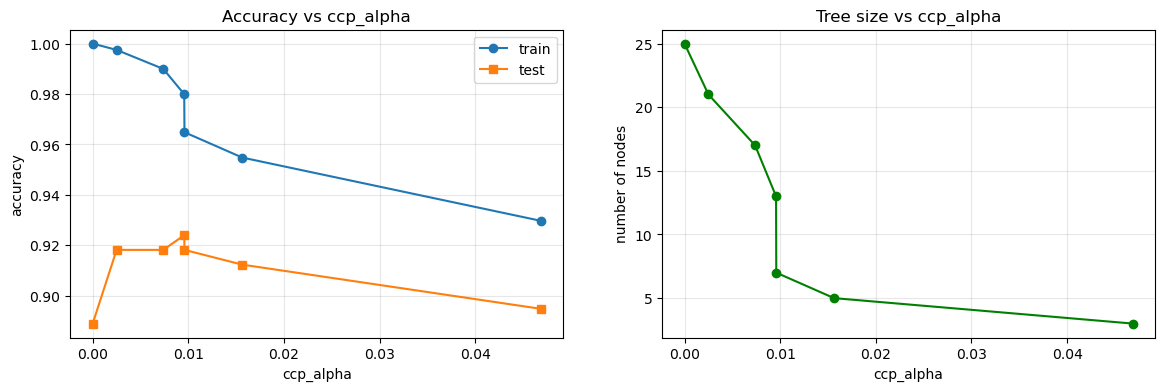

In [48]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(14,4))
ax[0].plot(ccp, train_score, 'o-', label='train')
ax[0].plot(ccp, test_score, 's-', label='test')
ax[0].set_xlabel('ccp_alpha'); ax[0].set_ylabel('accuracy'); ax[0].legend()
ax[0].set_title('Accuracy vs ccp_alpha'); ax[0].grid(alpha=0.3)
ax[1].plot(ccp, n_node, 'o-', color='green')
ax[1].set_xlabel('ccp_alpha'); ax[1].set_ylabel('number of nodes')
ax[1].set_title('Tree size vs ccp_alpha'); ax[1].grid(alpha=0.3)
plt.show()

### 최적의 alpha 값은??

In [93]:
best_i = int(np.argmax(test_score))
best_alpha = ccp[best_i]
print(f'최적 ccp_alpha = {best_alpha:.5f}')
print(f'  테스트 정확도 {test_score[best_i]:.4f} | 노드 수 {n_node[best_i]}')

full = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)
print(f'가지치기 전  : 정확도 {full.score(X_test,y_test):.4f} | 노드 수 {full.tree_.node_count}')

최적 ccp_alpha = 0.00957
  테스트 정확도 0.9240 | 노드 수 13
가지치기 전  : 정확도 0.8704 | 노드 수 25


### 인코딩 종류 및 방법

In [51]:
data = pd.read_csv('./data/mushroom.csv')
y = (data['poisonous']=='p').astype(int)
X_raw = data.drop(columns=['poisonous'])

In [52]:
X_raw

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,k,s,n,f,n,a,c,b,y,e,...,s,o,o,p,o,o,p,b,c,l
8120,x,s,n,f,n,a,c,b,y,e,...,s,o,o,p,n,o,p,b,v,l
8121,f,s,n,f,n,a,c,b,n,e,...,s,o,o,p,o,o,p,b,c,l
8122,k,y,n,f,y,f,c,n,b,t,...,k,w,w,p,w,o,e,w,v,l


In [54]:
# 원핫 인코딩
X_onehot = pd.get_dummies(X_raw)

from sklearn.preprocessing import LabelEncoder
# 레이블 인코딩
X_label = X_raw.copy()
for col in X_label.columns:
    X_label[col] = LabelEncoder().fit_transform(X_label[col])

### 성능 비교

In [57]:
# 동일 모델로 평가를 위한 선언
label = DecisionTreeClassifier(max_depth = 5, random_state = 0)

cv01 = cross_val_score(label, X_onehot, y, cv = 5).mean()
cv02 = cross_val_score(label, X_label, y, cv = 5).mean()

print(cv01)
print(cv02)

0.966995680181887
0.894976582038651


## KNN 심화 / Scaling의 효과 검증

In [58]:
# proline은 1,000단위, flavanoids는 1 단위 → 거리 계산을 진행하면 proline의 값이 거리의 대부분을 차지할 것

In [62]:
from sklearn.datasets import load_wine
wine = load_wine()

In [64]:
wine.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [67]:
wine['target_names']

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [68]:
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [70]:
wine['data'].shape

(178, 13)

In [71]:
wine['target'].shape

(178,)

In [73]:
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)

### Scaling 전 KNN의 성능

In [78]:
from sklearn.neighbors import KNeighborsClassifier

X, y = wine.data, wine.target
knn = KNeighborsClassifier(n_neighbors=7)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=8, stratify=y)

knn.fit(X_train, y_train)
raw_score = knn.score(X_test,y_test)
raw_score

0.6666666666666666

- **StandardScaler**: 평균 0, 표준편차 1 (가장 일반적)
- **MinMaxScaler**: 0~1 사이로 압축
- **RobustScaler**: 중앙값·사분위수 기준 (이상치에 강함)

In [95]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

scalers = {
    '기본': None,
    'Standard' : StandardScaler(),
    'MinMax' : MinMaxScaler(),
    'Robust' : RobustScaler()
}

for name, scaler in scalers.items():
    if scaler is None:
        X_tr, X_te = X_train, X_test
    else:
        scaler.fit(X_train)
        X_tr, X_te = scaler.transform(X_train), scaler.transform(X_test)
    acc = KNeighborsClassifier(n_neighbors = 7).fit(X_tr, y_train).score(X_te,y_test)
    print(f'{name:<16} 정확도 {acc:.4f}')

기본               정확도 0.6667
Standard         정확도 0.9444
MinMax           정확도 0.9259
Robust           정확도 0.9259


In [ ]:
#### KNN의 n_neighbors를 바꿔가며 진행해서 결과 살펴보기!

C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


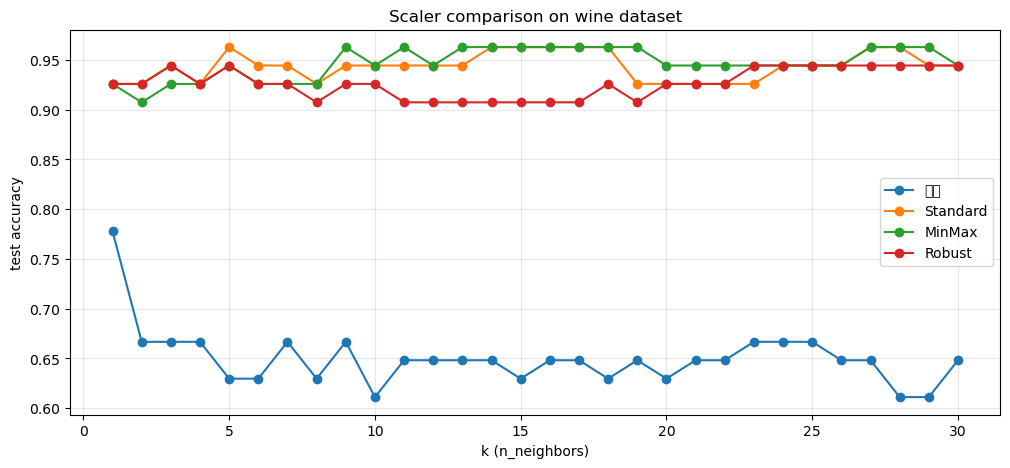

In [96]:
plt.figure(figsize=(12,5))
ks = range(1,31)

for name, sc in scalers.items():
    if sc is None:
        Xtr, Xte = X_train, X_test
    else:
        sc.fit(X_train); Xtr, Xte = sc.transform(X_train), sc.transform(X_test)
    accs = [KNeighborsClassifier(n_neighbors=k).fit(Xtr,y_train).score(Xte,y_test) for k in ks]
    plt.plot(list(ks), accs, marker='o', label=name)

plt.xlabel('k (n_neighbors)'); plt.ylabel('test accuracy')
plt.title('Scaler comparison on wine dataset'); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 차원의 저주 / Noise를 추가함에 따른 성능 변화

In [87]:
X, y = load_wine(return_X_y=True)
X = StandardScaler().fit_transform(X)
ran = np.random.RandomState(1)   # RandomState(N) → N이 변함에 따라 결과가 다르게 나오는것으로 점수가 튀는것은 운

n_noise = [0,5,10,20,50,100,200]
score = []

for n in n_noise:
    noise = ran.normal(size=(X.shape[0],n))
    X_noi = np.hstack([X, noise]) if n > 0 else X
    score.append(cross_val_score(KNeighborsClassifier(7), X_noi, y, cv=5).mean())
score

[np.float64(0.9665079365079364),
 np.float64(0.9384126984126985),
 np.float64(0.9553968253968254),
 np.float64(0.9155555555555555),
 np.float64(0.9219047619047618),
 np.float64(0.881904761904762),
 np.float64(0.7365079365079366)]

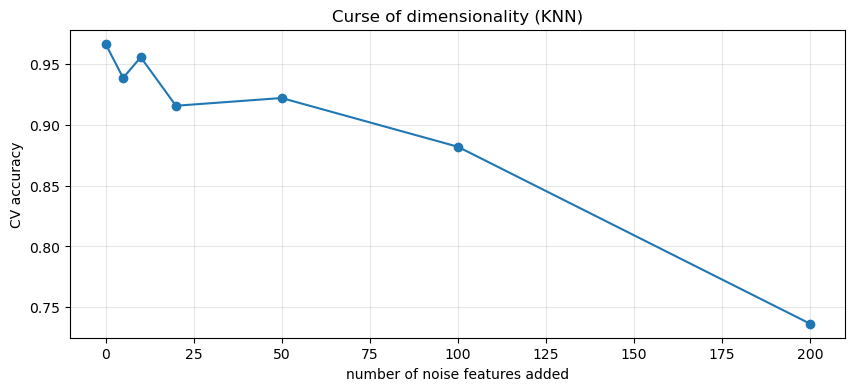

In [88]:
plt.figure(figsize=(10,4))
plt.plot(n_noise, score, 'o-')
plt.xlabel('number of noise features added'); plt.ylabel('CV accuracy')
plt.title('Curse of dimensionality (KNN)'); plt.grid(alpha=0.3); plt.show()